In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error

import chardet
file_path = 'IRENA_RenewableEnergy_Statistics_2000-2022.csv'

with open(file_path, 'rb') as f:
    result = chardet.detect(f.read())

irena = pd.read_csv(file_path, encoding=result['encoding'])

X = irena.drop(columns=['Electricity Generation (GWh)'])
y = irena['Electricity Generation (GWh)']

# One-hot encode categoricals
X_encoded = pd.get_dummies(X, drop_first=True)

# Simple random split (you can later switch to time-based split if you want)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [3]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

def run_rf_random_search(X_train, y_train, n_iter=50, cv=3):
    # Parameter distributions
    param_dist = {
        "n_estimators": randint(50, 500),     # 50 → 500 trees
        "max_depth": [None] + list(range(5, 31, 5)),  # None, 5,10,15,20,25,30
        "min_samples_split": randint(2, 21), # 2 → 20
        "min_samples_leaf": randint(1, 11),  # 1 → 10
    }

    rf_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    rand_search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        return_train_score=True
    )

    rand_search.fit(X_train, y_train)

    # Collect results
    results = pd.DataFrame(rand_search.cv_results_)
    results["MSE"] = -results["mean_test_score"]
    results["RMSE"] = np.sqrt(results["MSE"])

    results_sorted = results.sort_values("RMSE").reset_index(drop=True)

    print("Best params:", rand_search.best_params_)
    print("Best CV RMSE:", np.sqrt(-rand_search.best_score_))

    return rand_search, results_sorted

In [4]:
rf_search, rf_results = run_rf_random_search(
    X_train,
    y_train,
    n_iter=50,
    cv=3
)

best_rf_model = rf_search.best_estimator_

y_pred_test = best_rf_model.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)
print("RF Test RMSE:", test_rmse)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 97}
Best CV RMSE: 15386.832250406378
RF Test RMSE: 17695.06459548966


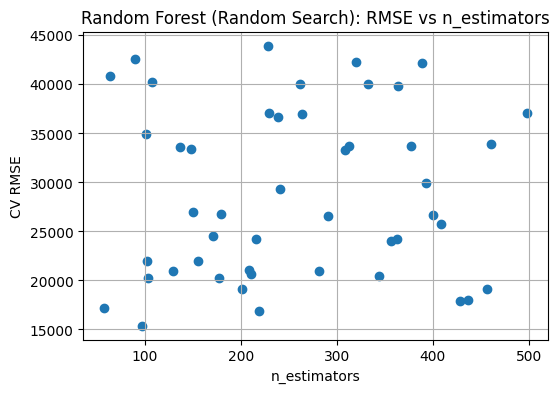

In [5]:
def plot_rmse_vs_n_estimators(results):
    plot_df = (
        results
        .groupby("param_n_estimators")["RMSE"]
        .min()
        .reset_index()
        .sort_values("param_n_estimators")
    )

    plt.figure(figsize=(6, 4))
    plt.scatter(plot_df["param_n_estimators"], plot_df["RMSE"])
    plt.xlabel("n_estimators")
    plt.ylabel("CV RMSE")
    plt.title("Random Forest (Random Search): RMSE vs n_estimators")
    plt.grid(True)
    plt.show()

plot_rmse_vs_n_estimators(rf_results)

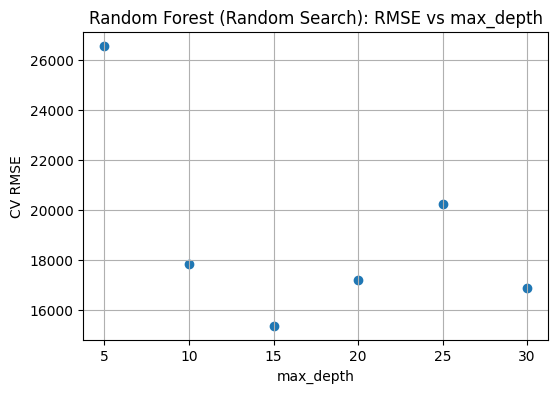

In [6]:
def plot_rmse_vs_depth(results):
    plot_df = (
        results
        .groupby("param_max_depth")["RMSE"]
        .min()
        .reset_index()
        .sort_values("param_max_depth")
    )

    plt.figure(figsize=(6, 4))
    plt.scatter(plot_df["param_max_depth"], plot_df["RMSE"])
    plt.xlabel("max_depth")
    plt.ylabel("CV RMSE")
    plt.title("Random Forest (Random Search): RMSE vs max_depth")
    plt.grid(True)
    plt.show()

plot_rmse_vs_depth(rf_results)

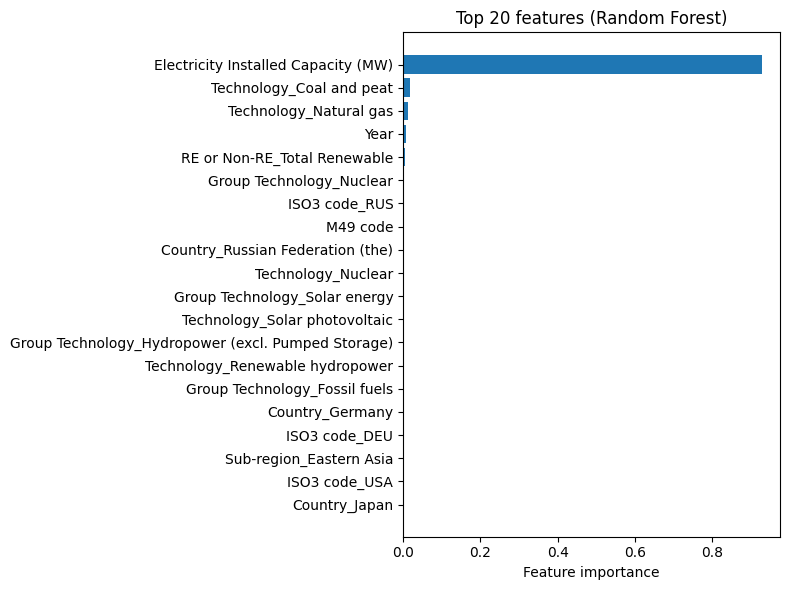

In [8]:
def plot_feature_importance(model, feature_names, top_n=20):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_n]

    plt.figure(figsize=(8, 6))
    plt.barh(np.array(feature_names)[idx][::-1], importances[idx][::-1])
    plt.xlabel("Feature importance")
    plt.title(f"Top {top_n} features (Random Forest)")
    plt.tight_layout()
    plt.show()

plot_feature_importance(best_rf_model, X_encoded.columns, top_n=20)

In [13]:
def plot_grouped_importance(model, feature_names):
    import pandas as pd

    importances = model.feature_importances_
    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })

    # Assign feature groups based on column name
    df["group"] = "Other"
    df.loc[df["feature"].str.startswith("Country_"), "group"] = "Country"
    df.loc[df["feature"].str.startswith("Region_"), "group"] = "Region"
    df.loc[df["feature"].str.startswith("Technology_"), "group"] = "Technology"
    df.loc[df["feature"].str.contains("Year", case=False), "group"] = "Year"

    grouped = (
        df
        .groupby("group")["importance"]
        .sum()
        .sort_values(ascending=True)
    )

    plt.figure(figsize=(6, 4))
    grouped.plot(kind="barh")
    plt.xlabel("Total Importance")
    plt.title("Feature Importance by Group (Random Forest)")
    plt.tight_layout()
    plt.show()

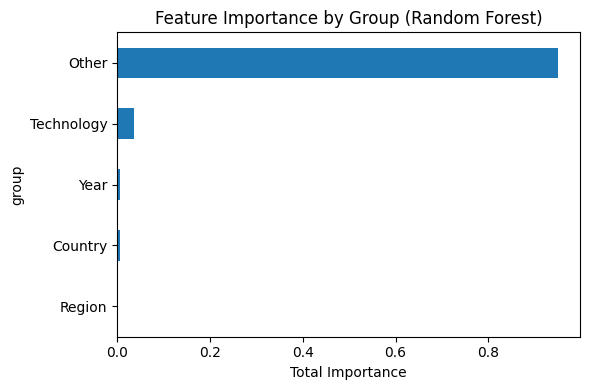

In [14]:
plot_grouped_importance(best_rf, X_encoded.columns)